# Métricas SaaS — MRR, ARR, NRR, churn, CAC y LTV

Todo lo que sigue lee **solo** de las vistas `gold_v_*` — ninguna regla de negocio
vive en este notebook ni en Power BI, vive en `sql/02_vistas_gold.sql`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
con = sqlite3.connect(ROOT / "db" / "saas_metrics.db")

# Paleta (dataviz skill): asignacion fija por rol, nunca por rango/valor.
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA, VERDE = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"
BUENO, CRITICO = "#0ca30c", "#d03b3b"
TINTA_SEC, MUTED, GRID = "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": TINTA_SEC,
    "xtick.color": TINTA_SEC, "ytick.color": TINTA_SEC,
    "grid.color": GRID, "font.size": 10,
})

resumen = pd.read_sql_query("SELECT * FROM gold_v_resumen_ejecutivo", con)
resumen

,id_periodo,nombre_mes,anio,mrr_total,arr_total,clientes_activos,nrr_pct,churn_logos_pct,churn_ingreso_pct,mrr_nuevo,mrr_expansion,mrr_contraccion,mrr_churn,mrr_reactivacion
0,202401,Enero,2024,8254340.0,99052080.0,28,NaN,NaN,NaN,8254340.0,0.0,0.0,0.0,0.0
1,202402,Febrero,2024,12945770.0,155349240.0,44,106.7,0.00,0.00,4141430.0,550000.0,0.0,0.0,0.0
2,202403,Marzo,2024,21257752.0,255093024.0,67,95.0,2.27,1.15,8962480.0,600000.0,1101498.0,149000.0,0.0
3,202404,Abril,2024,24617591.0,295411092.0,80,94.3,4.48,3.98,4564430.0,200000.0,557591.0,847000.0,0.0
4,202405,Mayo,2024,33496591.0,401959092.0,101,101.0,2.50,1.21,8627000.0,750000.0,200000.0,298000.0,0.0
5,202406,Junio,2024,40041641.0,480499692.0,112,106.7,1.98,0.89,4294050.0,3350000.0,950000.0,298000.0,149000.0
6,202407,Julio,2024,45983949.0,551807388.0,126,99.2,3.57,3.01,6244240.0,1100000.0,200000.0,1206916.0,0.0
7,202408,Agosto,2024,54846460.0,658157520.0,143,104.3,1.59,0.65,6552080.0,2809431.0,550000.0,298000.0,0.0
8,202409,Septiembre,2024,59979290.0,719751480.0,163,97.4,1.40,1.27,6580830.0,1300000.0,2050000.0,698000.0,0.0
9,202410,Octubre,2024,59220608.0,710647296.0,157,98.7,3.68,2.49,0.0,2050000.0,1314682.0,1494000.0,0.0


## 1. MRR Waterfall — diciembre 2024

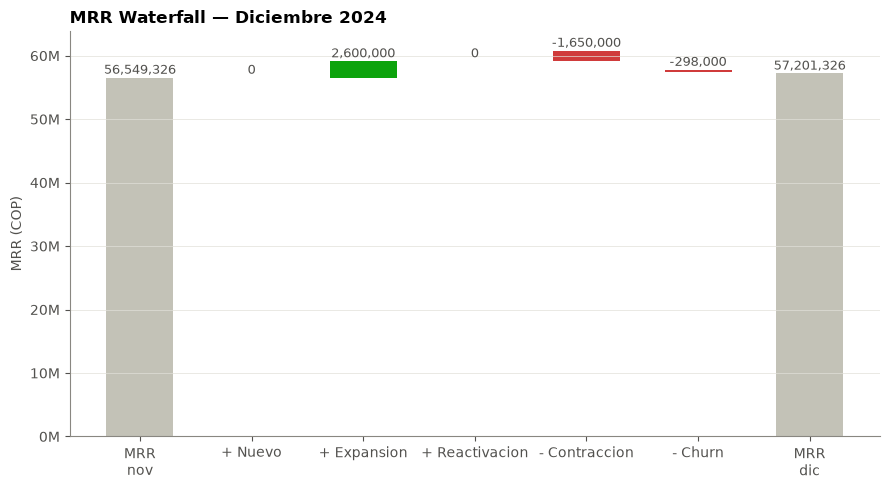

In [2]:
fila = resumen[resumen.id_periodo == 202412].iloc[0]
etiquetas = ["MRR\nnov", "+ Nuevo", "+ Expansion", "+ Reactivacion", "- Contraccion", "- Churn", "MRR\ndic"]
mrr_nov = resumen[resumen.id_periodo == 202411].iloc[0]["mrr_total"]
valores = [mrr_nov, fila.mrr_nuevo, fila.mrr_expansion, fila.mrr_reactivacion, -fila.mrr_contraccion, -fila.mrr_churn, fila.mrr_total]

acumulado = [0]
for v in valores[1:-1]:
    acumulado.append(acumulado[-1] + v)
base = [mrr_nov + a for a in acumulado[:-1]]

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#c3c2b7"] + [BUENO if v > 0 else CRITICO for v in valores[1:-1]] + ["#c3c2b7"]
alturas = [valores[0]] + [abs(v) for v in valores[1:-1]] + [valores[-1]]
fondos = [0] + base + [0]
ax.bar(etiquetas, alturas, bottom=fondos, color=colores, width=0.6)
for i, (h, f) in enumerate(zip(alturas, fondos)):
    ax.text(i, f + h + resumen.mrr_total.max() * 0.01, f"{valores[i]:,.0f}", ha="center", fontsize=9, color=TINTA_SEC)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f}M"))
ax.set_ylabel("MRR (COP)")
ax.set_title("MRR Waterfall — Diciembre 2024", loc="left", fontweight="bold")
ax.grid(axis="y", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{ROOT}/docs/img_mrr_waterfall.png", dpi=130)
plt.show()

## 2. NRR mensual

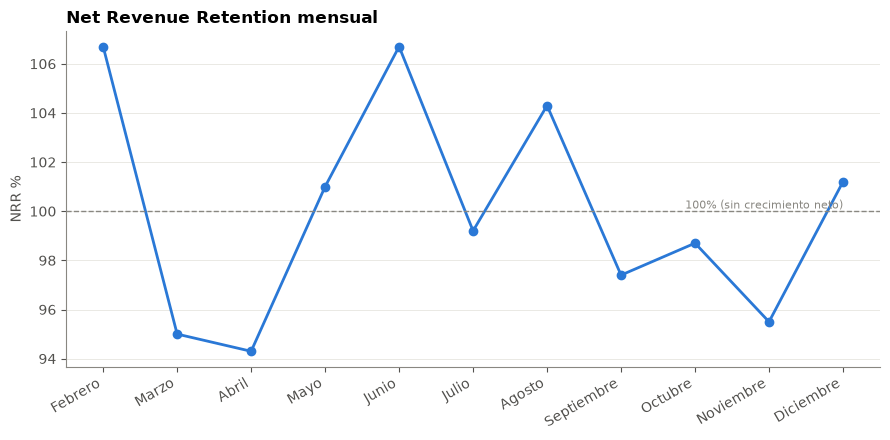

NRR promedio: 100.0%  |  min: 94.3%  |  max: 106.7%


In [3]:
nrr = pd.read_sql_query("SELECT * FROM gold_v_nrr_mensual", con)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(nrr.nombre_mes, nrr.nrr_pct, marker="o", color=AZUL, linewidth=2)
ax.axhline(100, color=MUTED, linestyle="--", linewidth=1)
ax.text(len(nrr) - 1, 100, " 100% (sin crecimiento neto)", va="bottom", ha="right", fontsize=8, color=MUTED)
ax.set_ylabel("NRR %")
ax.set_title("Net Revenue Retention mensual", loc="left", fontweight="bold")
ax.grid(axis="y", linewidth=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{ROOT}/docs/img_nrr.png", dpi=130)
plt.show()
print(f"NRR promedio: {nrr.nrr_pct.mean():.1f}%  |  min: {nrr.nrr_pct.min():.1f}%  |  max: {nrr.nrr_pct.max():.1f}%")

## 3. Churn — logos vs. ingreso

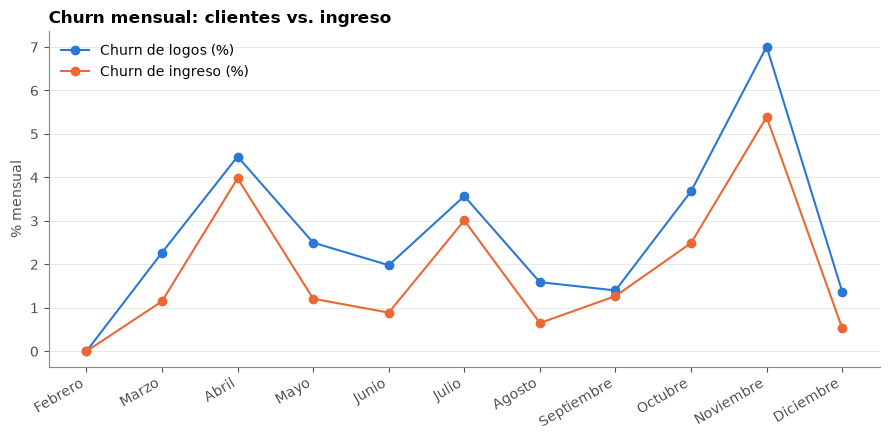

In [4]:
churn = pd.read_sql_query("SELECT * FROM gold_v_churn", con)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(churn.nombre_mes, churn.churn_logos_pct, marker="o", color=AZUL, label="Churn de logos (%)")
ax.plot(churn.nombre_mes, churn.churn_ingreso_pct, marker="o", color=NARANJA, label="Churn de ingreso (%)")
ax.set_ylabel("% mensual")
ax.set_title("Churn mensual: clientes vs. ingreso", loc="left", fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{ROOT}/docs/img_churn.png", dpi=130)
plt.show()

## 4. Retención por cohorte

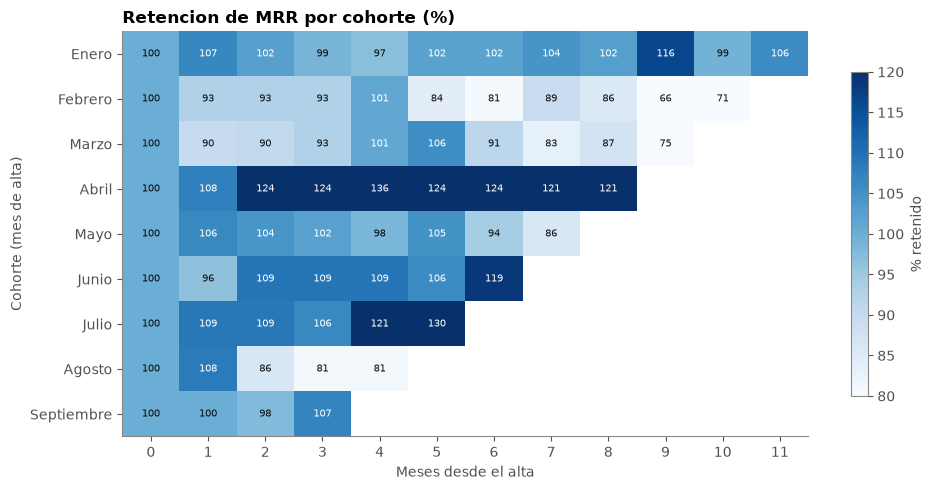

In [5]:
cohortes = pd.read_sql_query("SELECT * FROM gold_v_cohortes", con)
pivote = cohortes.pivot(index="mes_cohorte", columns="meses_desde_alta", values="pct_retencion")
orden_meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre"]
pivote = pivote.reindex([m for m in orden_meses if m in pivote.index])

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivote.values, cmap="Blues", vmin=80, vmax=120, aspect="auto")
ax.set_xticks(range(pivote.shape[1])); ax.set_xticklabels(pivote.columns)
ax.set_yticks(range(pivote.shape[0])); ax.set_yticklabels(pivote.index)
ax.set_xlabel("Meses desde el alta"); ax.set_ylabel("Cohorte (mes de alta)")
ax.set_title("Retencion de MRR por cohorte (%)", loc="left", fontweight="bold")
for i in range(pivote.shape[0]):
    for j in range(pivote.shape[1]):
        v = pivote.values[i, j]
        if not pd.isna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                     color="white" if v > 100 else "#0b0b0b")
plt.colorbar(im, ax=ax, label="% retenido", shrink=0.8)
plt.tight_layout()
plt.savefig(f"{ROOT}/docs/img_cohortes.png", dpi=130)
plt.show()

## 5. CAC por canal (gasto total del año / clientes nuevos del año)

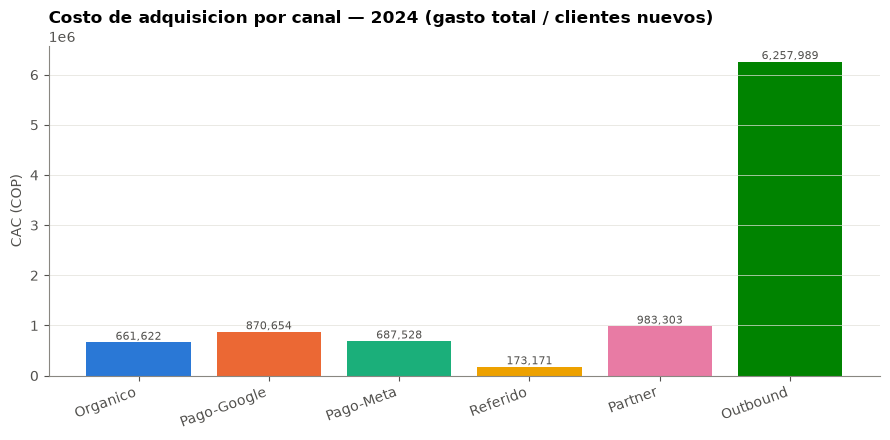

,gasto_total,clientes_nuevos,cac_cop
nombre_canal,,,
Organico,23156772,35,6.616221e+05
Pago-Google,31343561,36,8.706545e+05
Pago-Meta,26813576,39,6.875276e+05
Referido,5714656,33,1.731714e+05
Partner,13766239,14,9.833028e+05
Outbound,93869833,15,6.257989e+06


In [6]:
cac = pd.read_sql_query("SELECT * FROM gold_v_cac_por_canal", con)
cac_anual = cac.groupby("nombre_canal").agg(gasto_total=("gasto_cop", "sum"), clientes_nuevos=("clientes_nuevos", "sum"))
cac_anual["cac_cop"] = cac_anual.gasto_total / cac_anual.clientes_nuevos
orden_canales = ["Organico", "Pago-Google", "Pago-Meta", "Referido", "Partner", "Outbound"]
cac_anual = cac_anual.reindex(orden_canales)
colores_canal = [AZUL, NARANJA, AQUA, AMARILLO, MAGENTA, VERDE]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(cac_anual.index, cac_anual.cac_cop, color=colores_canal)
for i, v in enumerate(cac_anual.cac_cop):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8, color=TINTA_SEC)
ax.set_ylabel("CAC (COP)")
ax.set_title("Costo de adquisicion por canal — 2024 (gasto total / clientes nuevos)", loc="left", fontweight="bold")
ax.grid(axis="y", linewidth=0.5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{ROOT}/docs/img_cac.png", dpi=130)
plt.show()
cac_anual

## 6. LTV por plan

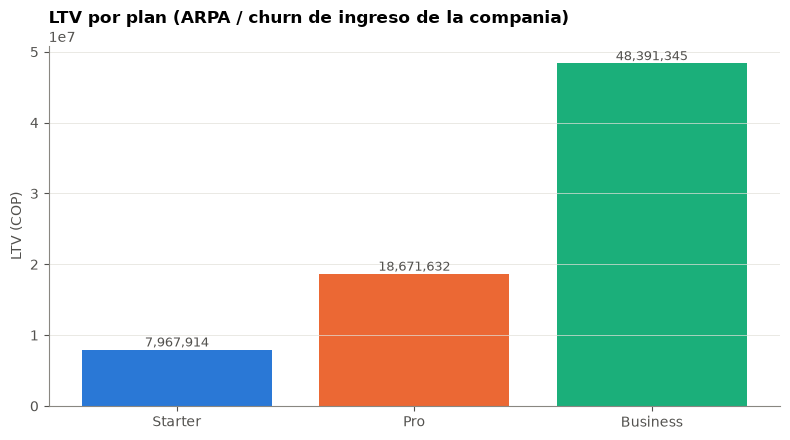

,arpa_cop,churn_mensual_promedio_pct,ltv_cop,churn_ingreso_plan_pct,ltv_cop_churn_plan,bajas_plan
nombre_plan,,,,,,
Starter,149000.00,1.87,7967914.44,3.94,3.777150e+06,20
Pro,349159.53,1.87,18671632.36,3.05,1.145231e+07,14
Business,904918.15,1.87,48391344.74,0.50,1.816067e+08,1


In [7]:
ltv = pd.read_sql_query("SELECT * FROM gold_v_ltv", con).set_index("nombre_plan").reindex(["Starter", "Pro", "Business"])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ltv.index, ltv.ltv_cop, color=[AZUL, NARANJA, AQUA])
for i, v in enumerate(ltv.ltv_cop):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, color=TINTA_SEC)
ax.set_ylabel("LTV (COP)")
ax.set_title("LTV por plan (ARPA / churn de ingreso de la compania)", loc="left", fontweight="bold")
ax.grid(axis="y", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{ROOT}/docs/img_ltv.png", dpi=130)
plt.show()
ltv

## Hallazgos clave

- El **NRR** se mueve entre 94,3 % y 106,7 % y queda **bajo 100 % en 6 de 11 meses**
  (marzo, abril, julio, septiembre, octubre y noviembre). De octubre a diciembre no hay
  altas por un supuesto de la simulación: esa caída del MRR no es un problema comercial.
- El **churn de ingreso** es menor que el **churn de logos** en 10 de los 11 meses
  medidos (febrero no tuvo bajas): los clientes que se van tienden a ser de planes baratos.
- **Referido** tiene el CAC más bajo (173.171 COP) y **Outbound** el más alto
  (6.257.989 COP, unas 36 veces más).
- Para decidir sobre Outbound hay que mirar LTV:CAC, no solo el CAC. Con el LTV principal
  (churn de toda la compañía), un Starter traído por Outbound rinde ≈1,3x, por debajo del
  umbral de referencia 3:1. Con el churn propio de Starter (3,94 %) el LTV baja a ≈3,8M
  y queda por debajo del CAC de Outbound: ese cliente no recupera lo que costó.
- El LTV principal de **Business** (48,4M) es el más alto **solo por ARPA**: `ltv_cop` usa
  el mismo churn para los tres planes. La sensibilidad por plan sugiere que Business
  también se va menos (0,50 %), pero con una sola baja en el año no es concluyente.

In [8]:
import subprocess, sys
resultado = subprocess.run([sys.executable, "exportar_csv.py"], cwd=ROOT, capture_output=True, text=True)
print(resultado.stdout)
if resultado.returncode != 0:
    print(resultado.stderr)

  dim_periodo.csv: 24 filas
  dim_cliente.csv: 247 filas
  dim_plan.csv: 3 filas
  dim_canal.csv: 6 filas
  gold_v_eventos_detalle.csv: 283 filas
  gold_v_resumen_ejecutivo.csv: 12 filas
  gold_v_mrr_movements.csv: 12 filas
  gold_v_arr_mrr.csv: 12 filas
  gold_v_nrr_mensual.csv: 11 filas
  gold_v_churn.csv: 11 filas
  gold_v_cohortes.csv: 72 filas
  gold_v_cac_por_canal.csv: 72 filas
  gold_v_ltv.csv: 3 filas
  gold_v_ltv_cac_por_canal.csv: 6 filas
  gold_v_calidad_clientes.csv: 247 filas
  gold_v_resumen_calidad.csv: 5 filas
  gold_v_calidad_cuarentena.csv: 1 filas

17 archivos exportados a powerbi/

